In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(dplyr))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

donors <- c('C29', 'C37', 'C38', 'C39')
donor_hexes <- c('#2851B0', '#C445B8', '#70373D', '#CFCF42')

base_theme <- theme(
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### A: TRA1-60+ colony counts

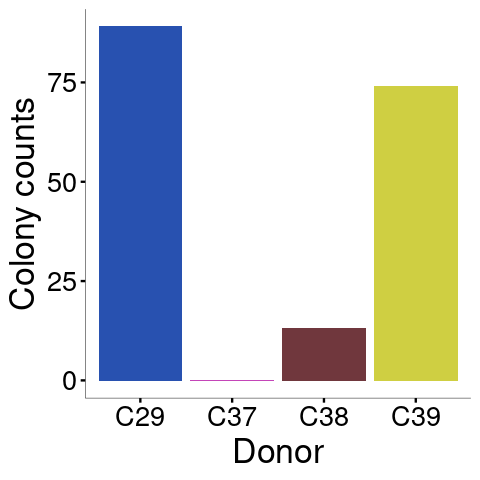

In [ ]:
counts <- c(89, 0, 13, 74)

colony_df <- data.frame(donor = donors, colony_counts = counts)

w = 4
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(colony_df, aes(x = donor, y = colony_counts, fill=donor)) +
  geom_bar(stat='identity', position='dodge') +
  labs(x = "Donor", y = "Colony counts") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_text(size=16, color='black'),
        axis.text.y = element_text(size=16, color='black'),
        axis.ticks.x = element_line(color='black'),
        axis.ticks.y = element_line(color='black'),
        axis.line.x = element_line(color='black', linewidth=0.1),
        axis.line.y = element_line(color='black', linewidth=0.1),
        axis.title.x = element_text(size=20, color='black'),
        axis.title.y = element_text(size=20, color='black'),
        ) +
    scale_fill_manual(values=donor_hexes)

### B: singlets per demultiplexing method

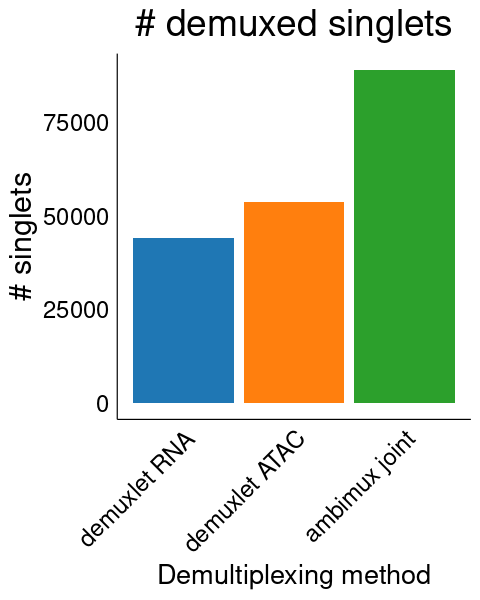

In [ ]:
demux_order <- c('demuxlet RNA', 'demuxlet ATAC', 'ambimux joint')
demux_hexes <- c('#1F77B4', '#FF7F0E', '#2CA02C')
demux <- as.data.frame(fread(paste0(projdir, '/csv/figure1/ambimux_demuxlet.csv'), sep='\t', header=FALSE))
demux <- demux[-1,]
colnames(demux) <- c('index', 'singlets', 'method')
demux$method <- factor(demux$method, levels=demux_order)

w = 4
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(demux, aes(x = method, y = singlets, fill=method)) +
  geom_bar(stat = "identity") +
  labs(x = "Demultiplexing method", y = "# singlets", title = "# demuxed singlets") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 14, angle = 45, hjust = 1, color = "black"),
    axis.text.y = element_text(size = 14, color = "black"),
    axis.title.x = element_text(size = 16),
    axis.title.y = element_text(size = 18),
    plot.title = element_text(hjust=0.5, size=22),
    axis.line = element_line(color='black', linewidth=0.25),
    panel.grid = element_blank()
  ) +
  scale_fill_manual(values=demux_hexes)

### C: donor proportion per day

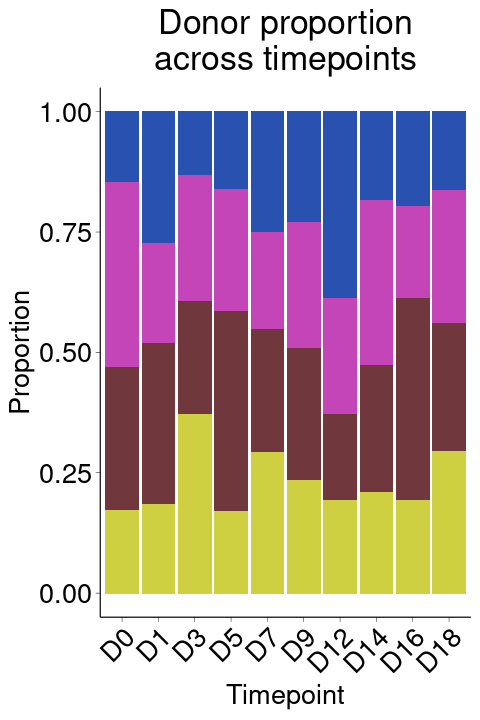

In [ ]:
ambimux_path <- paste0(projdir, '/csv/figure1/ambimux_timepoints.csv')
ambimux = as.data.frame(fread(ambimux_path, sep='\t',header=TRUE))

result <- ambimux %>%
  group_by(time_num, value) %>%
  summarise(n = n(), .groups = "drop")

result <- result %>%
  group_by(time_num) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

tmp_times <- paste0('D', unique(result$time_num))
result$time <- paste0('D', result$time_num)
result$time <- factor(result$time, levels=tmp_times)

w = 4
h = 6
options(repr.plot.width=w, repr.plot.height=h)

ggplot(result, aes(x = time, y = prop, fill = value)) +
  geom_bar(stat='identity', position='stack') +
  labs(x = "Timepoint",y = "Proportion", title = "Donor proportion\nacross timepoints") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x  = element_text(size = 16, angle = 45, hjust = 1, color = "black"),
    axis.text.y  = element_text(size = 16, color = "black"),
    axis.title.x = element_text(size = 16),
    axis.title.y = element_text(size = 16),
    axis.line = element_line(color='black', linewidth=0.25),
    axis.ticks.x = element_line(color='black', linewidth=0.1),
    axis.ticks.y = element_line(color='black', linewidth=0.1),
    plot.title   = element_text(size = 20, hjust = 0.5),
    legend.position = "none") +
  scale_fill_manual(values = donor_hexes)

### D: 10x Multiome RNA UMIs

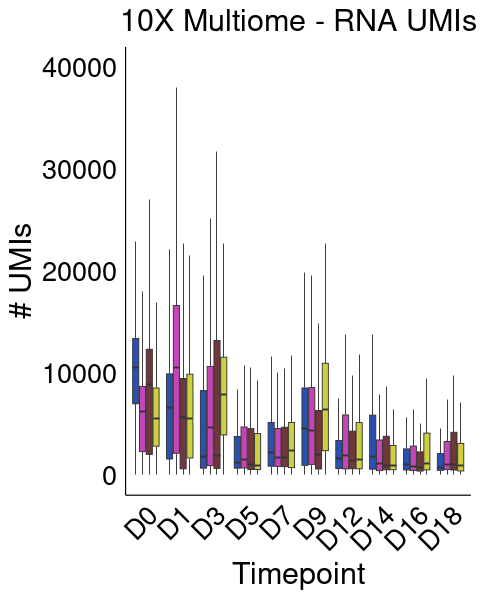

In [ ]:
mult_qc_path <- paste0(projdir, '/csv/figure1/10x_qc.csv')
mult_qc = as.data.frame(fread(mult_qc_path, sep='\t',header=TRUE))
mult_qc$time <- factor(mult_qc$time, levels=tmp_times)

w = 4
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(mult_qc, aes(x = time, y = gex_umis_count, fill = assignment)) +
  geom_boxplot(width=0.8, linewidth = 0.2, outlier.shape = NA) +
  scale_y_continuous(limits = c(0, 4e4)) +
  scale_fill_manual(values = donor_hexes) +
  labs(x = "Timepoint", y = "# UMIs", title = "10X Multiome - RNA UMIs") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 16, angle = 45, hjust = 1, color = "black"),
    axis.text.y = element_text(size = 16, color = "black"),
    axis.title.x = element_text(size = 18),
    axis.title.y = element_text(size = 18),
    plot.title = element_text(hjust=0.5, size=18),
    panel.grid = element_blank(),
    axis.line = element_line(color='black', linewidth=0.25),
  legend.position='none')

### E: 10x Multiome ATAC fragments

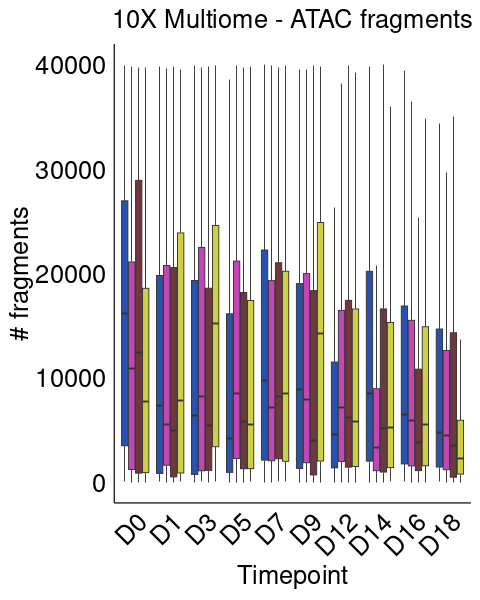

In [ ]:
w = 4
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(mult_qc, aes(x = time, y = atac_fragments, fill = assignment)) +
  geom_boxplot(width=0.8, linewidth = 0.2, outlier.shape = NA) +
  scale_y_continuous(limits = c(0, 4e4)) +
  scale_fill_manual(values = donor_hexes) +
  labs(x = "Timepoint", y = "# fragments", title = "10X Multiome - ATAC fragments") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 15, angle = 45, hjust = 1, color = "black"),
    axis.text.y = element_text(size = 15, color = "black"),
    axis.title.x = element_text(size = 15),
    axis.title.y = element_text(size = 15),
    plot.title = element_text(hjust=0.5, size=15),
    axis.line = element_line(color='black', linewidth=0.25),
    panel.grid = element_blank(),
  legend.position='none')

### F: snmCT-seq RNA transcript counts

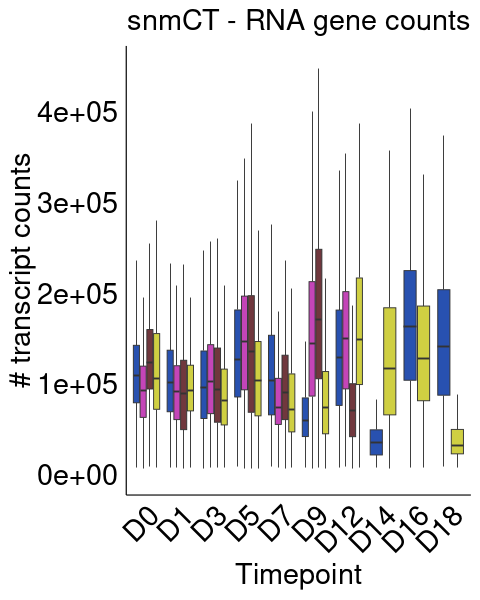

In [ ]:
snmct_path <- paste0(projdir, '/csv/figure1/snmct_meta.csv')
snmct = as.data.frame(fread(snmct_path, sep='\t'))
snmct$time <- factor(snmct$time, levels=tmp_times)

w = 4
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(snmct, aes(x = time, y = RNA_Combined_AssignedFragments_Gene, fill = line)) +
  geom_boxplot(width=0.8, linewidth = 0.2, outlier.shape = NA) +
  scale_y_continuous(limits = c(0, 4.5e5)) +
  scale_fill_manual(values = donor_hexes) +
  labs(x = "Timepoint", y = "# transcript counts", title = "snmCT - RNA gene counts") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 17, angle = 45, hjust = 1, color = "black"),
    axis.text.y = element_text(size = 17, color = "black"),
    axis.title.x = element_text(size = 17),
    axis.title.y = element_text(size = 17),
      plot.title = element_text(hjust=0.5, size=17),
    panel.grid = element_blank(),
    axis.line = element_line(color='black', linewidth=0.25),
  legend.position='none')

### G: snmCT-seq methylome reads

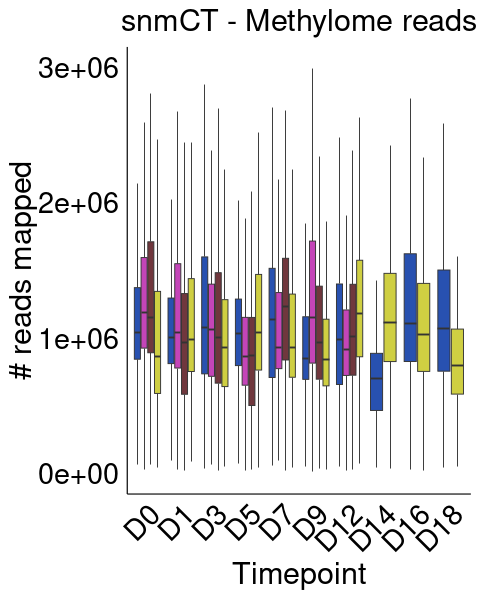

In [ ]:
w = 4
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(snmct, aes(x = time, y = DNA_Combined_UniqueMappedReads, fill = line)) +
  geom_boxplot(width=0.8, linewidth = 0.2, outlier.shape = NA) +
  scale_y_continuous(limits = c(0, 3e6)) +
  scale_fill_manual(values = donor_hexes) +
  labs(x = "Timepoint", y = "# reads mapped", title = "snmCT - Methylome reads") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 17, angle = 45, hjust = 1, color = "black"),
    axis.text.y = element_text(size = 17, color = "black"),
    axis.title.x = element_text(size = 18),
    axis.title.y = element_text(size = 18),
      plot.title = element_text(hjust=0.5, size=18),
    axis.line = element_line(color='black', linewidth=0.25),
    panel.grid = element_blank(),
  legend.position='none')

### H: snmCT-seq methylome coverage

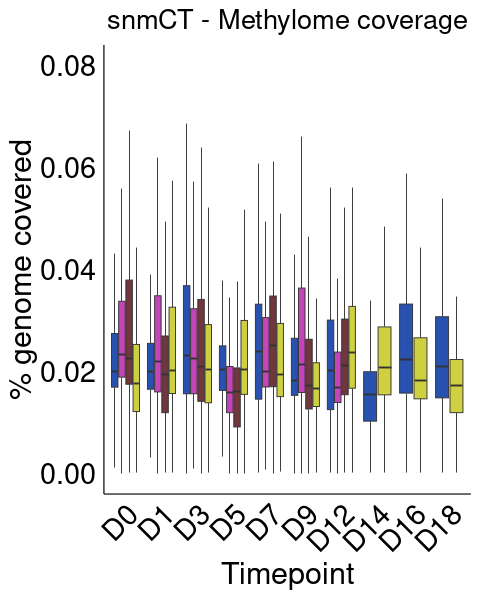

In [ ]:
w = 4
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(snmct, aes(x = time, y = DNA_CoveragePerc1x, fill = line)) +
  geom_boxplot(width=0.8, linewidth = 0.2, outlier.shape = NA) +
  scale_y_continuous(limits = c(0, 0.08)) +
  scale_fill_manual(values = donor_hexes) +
  labs(x = "Timepoint", y = "% genome covered", title = "snmCT - Methylome coverage") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 17, angle = 45, hjust = 1, color = "black"),
    axis.text.y = element_text(size = 17, color = "black"),
    axis.title.x = element_text(size = 18),
    axis.title.y = element_text(size = 18),
      plot.title = element_text(hjust=0.5, size=16),
    panel.grid = element_blank(),
    axis.line = element_line(color='black', linewidth=0.25),
  legend.position='none')

### I: snm3C-seq reads mapped

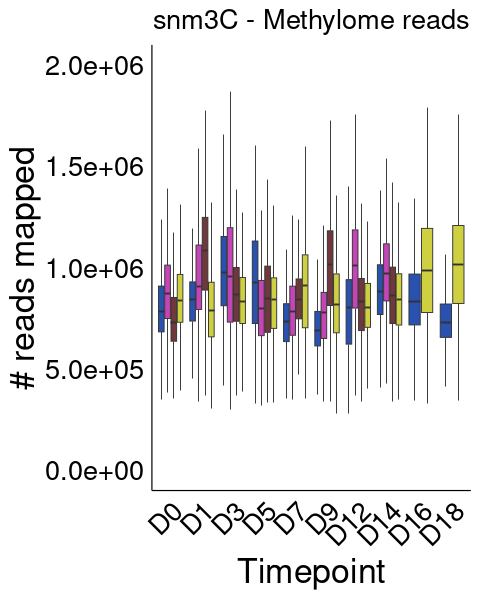

In [ ]:
snm3c_path <- paste0(projdir, '/csv/figure1/snm3c_meta.csv')
snm3c = as.data.frame(fread(snm3c_path, sep='\t'))
snm3c$time <- factor(snm3c$time, levels=tmp_times)

w = 4
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(snm3c, aes(x = time, y = UniqueMappedReads_PreSplit, fill = line)) +
  geom_boxplot(width=0.8, linewidth = 0.2, outlier.shape = NA) +
  scale_y_continuous(limits = c(0, 2e6), labels = label_scientific()) +
  scale_fill_manual(values = donor_hexes) +
  labs(x = "Timepoint", y = "# reads mapped", title = "snm3C - Methylome reads") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 16, angle = 45, hjust = 1, color = "black"),
    axis.text.y = element_text(size = 16, color = "black"),
    axis.title.x = element_text(size = 20),
    axis.title.y = element_text(size = 20),
      plot.title = element_text(hjust=0.5, size=16),
    panel.grid = element_blank(),
    axis.line = element_line(color='black', linewidth=0.25),
  legend.position='none')

### J: snm3C-seq contacts

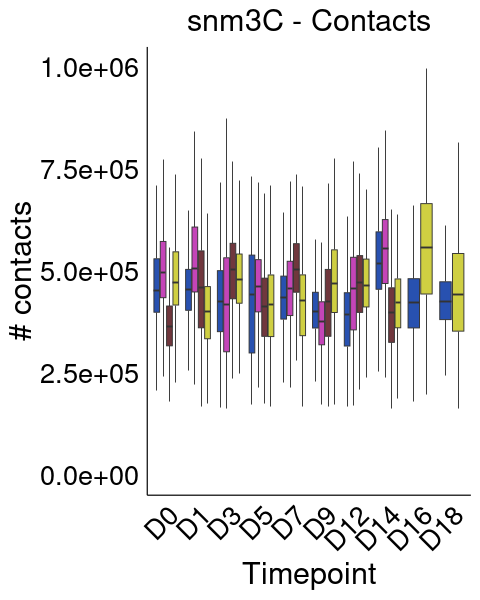

In [ ]:
w = 4
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(snm3c, aes(x = time, y = contacts_final, fill = line)) +
  geom_boxplot(width=0.8, linewidth = 0.2, outlier.shape = NA) +
  scale_y_continuous(limits = c(0, 1e6), labels = label_scientific()) +
  scale_fill_manual(values = donor_hexes) +
  labs(x = "Timepoint", y = "# contacts", title = "snm3C - Contacts") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 16, angle = 45, hjust = 1, color = "black"),
    axis.text.y = element_text(size = 16, color = "black"),
    axis.title.x = element_text(size = 18),
    axis.title.y = element_text(size = 18),
      plot.title = element_text(hjust=0.5, size=18),
    panel.grid = element_blank(),
    axis.line = element_line(color='black', linewidth=0.25),
  legend.position='none')

### K: snm3C-seq intra/inter ratio

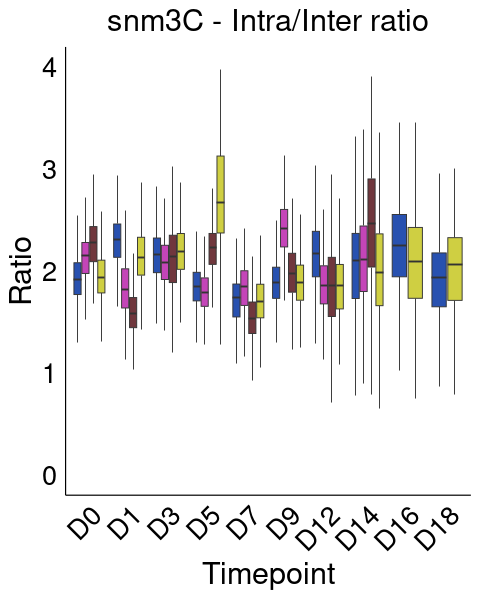

In [ ]:
w = 4
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(snm3c, aes(x = time, y = ratio_finalcont_intragreater1kb_inter, fill = line)) +
  geom_boxplot(width=0.8, linewidth = 0.2, outlier.shape = NA) +
  scale_y_continuous(limits = c(0, 4)) +
  scale_fill_manual(values = donor_hexes) +
  labs(x = "Timepoint", y = "Ratio", title = "snm3C - Intra/Inter ratio") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 16, angle = 45, hjust = 1, color = "black"),
    axis.text.y = element_text(size = 16, color = "black"),
    axis.title.x = element_text(size = 18),
    axis.title.y = element_text(size = 18),
      plot.title = element_text(hjust=0.5, size=18),
    panel.grid = element_blank(),
    axis.line = element_line(color='black', linewidth=0.25),
  legend.position='none')

In [ ]:
sessionInfo()

In [ ]:
Sys.time()